In [3]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 103.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 89.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 72.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 113.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.5 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 182.4 MB/s eta 0:00:00a 0:0

In [4]:
import os
import csv
import math
import random
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

!pip install pytorch_lightning -q
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from tqdm import tqdm

!pip install transformers datasets torchmetrics -q
from datasets import load_dataset
from transformers import PreTrainedTokenizerFast, get_cosine_with_min_lr_schedule_with_warmup, GPT2LMHeadModel, GPT2Tokenizer
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.decoders import BPEDecoder
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')
train_texts = dataset['train'].filter(lambda x: x['text'].strip() and not x['text'].startswith(' ='))['text']
val_texts = dataset['validation'].filter(lambda x: x['text'].strip() and not x['text'].startswith(' ='))['text']

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(
    vocab_size=4096,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"],
)
tokenizer.train_from_iterator(train_texts, trainer=trainer)

fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    pad_token="[PAD]",
    bos_token="[BOS]",
    eos_token="[EOS]",
    unk_token="[UNK]"
)

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/36718 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [6]:
train_texts[:3]

[' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character desi

In [7]:
BLOCK_SIZE = 256

class BlockDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size=BLOCK_SIZE):
        self.block_size = block_size
        tokens = []
        for text in texts:
            tokens.extend(tokenizer.encode(text, add_special_tokens=False))
        self.blocks = []
        for i in range(0, len(tokens) - block_size + 1, block_size):
            self.blocks.append(tokens[i:i+block_size])
    
    def __len__(self):
        return len(self.blocks)
    
    def __getitem__(self, idx):
        block = self.blocks[idx]
        x = torch.tensor(block, dtype=torch.long)
        y = torch.tensor(block[1:] + [0], dtype=torch.long)  # 0 = PAD_ID, будет игнорироваться
        return x, y

train_dataset = BlockDataset(train_texts, fast_tokenizer)
val_dataset   = BlockDataset(val_texts, fast_tokenizer)

In [8]:
class WikiTextDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, batch_size=64, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers, pin_memory=True)

In [9]:
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_layers=4, dim_feedforward=1024, dropout=0.2, max_seq_len=BLOCK_SIZE):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

        self.register_buffer("causal_mask", torch.triu(torch.ones(max_seq_len, max_seq_len, dtype=torch.bool), diagonal=1))
        
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids):
        seq_len = input_ids.size(1)
        token_emb = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        pos_emb = self.pos_embedding(positions)
        x = self.dropout(token_emb + pos_emb)

        attn_mask = self.causal_mask[:seq_len, :seq_len]
        out = self.encoder(x, mask=attn_mask, src_key_padding_mask=(input_ids == 0))
        logits = self.lm_head(out)
        return logits

In [10]:
class LitTransformer(pl.LightningModule):
    def __init__(self, model, lr=5e-4, weight_decay=0.01, total_steps=None):
        super().__init__()
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay
        self.total_steps = total_steps

    def forward(self, input_ids):
        return self.model(input_ids)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)  # (batch, seq_len, vocab)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=0)
        perplexity = torch.exp(loss)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_ppl', perplexity, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=0)
        perplexity = torch.exp(loss)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_ppl', perplexity, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)    
        scheduler = get_cosine_with_min_lr_schedule_with_warmup(
            optimizer=optimizer,
            num_warmup_steps=int(self.total_steps * 0.05),
            num_training_steps=self.total_steps,
            num_cycles=3,
            min_lr_rate=0.01,
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "step"}]

In [ ]:
MAX_EPOCHS = 100
BATCH_SIZE = 64
dm = WikiTextDataModule(train_dataset, val_dataset, batch_size=BATCH_SIZE)
total_steps = len(dm.train_dataloader()) * MAX_EPOCHS
print(total_steps)

In [ ]:
model = TinyTransformer(vocab_size=fast_tokenizer.vocab_size)
# for name, p in model.named_parameters():
#     print(name, p.numel())
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
lit_model = LitTransformer(model, lr=5e-4, total_steps=total_steps)
ckpt_last = ModelCheckpoint(
    dirpath='checkpoints',
    filename='tiny-transformer-last-{epoch:02d}',
)
ckpt_best = ModelCheckpoint(
    dirpath='checkpoints',
    filename='tiny-transformer-{epoch:02d}-{val_ppl:.2f}',
    monitor='val_ppl',
    mode='min',
    save_top_k=1
)
early_stop = EarlyStopping(monitor='val_ppl', patience=5, mode='min')
lr_monitor = LearningRateMonitor(logging_interval='step')

In [ ]:
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    callbacks=[ckpt_last, ckpt_best, early_stop, lr_monitor],
    logger=CSVLogger(save_dir='logs', name='tiny-transformer'),
    gradient_clip_val=1.0,
)
trainer.fit(lit_model, dm)

In [ ]:
df = pd.read_csv('logs/tiny-transformer/version_8/metrics.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_rows = df.dropna(subset=['train_loss'])
val_rows   = df.dropna(subset=['val_loss'])
axes[0].plot(train_rows['epoch'], train_rows['train_loss'], label='train')
axes[0].plot(val_rows['epoch'], val_rows['val_loss'], label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

train_rows = df.dropna(subset=['train_ppl'])
val_rows   = df.dropna(subset=['val_ppl'])
axes[1].plot(train_rows['epoch'], train_rows['train_ppl'], label='train')
axes[1].plot(val_rows['epoch'], val_rows['val_ppl'], label='val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_yscale('log')
axes[1].legend()

rows = df.dropna(subset=['lr-AdamW'])
axes[2].plot(rows['step'], rows['lr-AdamW'], label='lr')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('LR')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import FileLink
#FileLink('checkpoints/tiny-transformer-epoch=84-val_ppl=63.09.ckpt')
FileLink('logs/tiny-transformer/version_8/metrics.csv')

In [ ]:
os.listdir('checkpoints/')

In [ ]:
state_dict = torch.load('checkpoints/tiny-transformer-epoch=84-val_ppl=63.09.ckpt')['state_dict']
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.'):
        new_state_dict[k[6:]] = v
    else:
        new_state_dict[k] = v

model = TinyTransformer(vocab_size=fast_tokenizer.vocab_size)
model.load_state_dict(new_state_dict)
model.cuda()

In [ ]:
def generate(model, tokenizer, prompt, max_new_tokens=100, temperature=1.0, top_k=None, device='cuda'):
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False, return_tensors='pt').to(device)
    generated = input_ids[0].tolist()
    for _ in range(max_new_tokens):
        if len(generated) > model.pos_embedding.num_embeddings:
            generated = generated[-model.pos_embedding.num_embeddings:]

        input_tensor = torch.tensor([generated], device=device)
        with torch.no_grad():
            logits = model(input_tensor)
            next_token_logits = logits[0, -1, :] / temperature

        if top_k is not None:
            indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
            next_token_logits[indices_to_remove] = -float('Inf')

        probs = torch.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()

        if next_token == tokenizer.eos_token_id:
            break
        generated.append(next_token)

    generated_text = tokenizer.decode(generated, skip_special_tokens=True)
    return generated_text

In [ ]:
prompt = "The history of artificial intelligence"
generated_text = generate(model, fast_tokenizer, prompt, max_new_tokens=200, temperature=0.8, top_k=50)
print(generated_text)

In [45]:
ppl_model = GPT2LMHeadModel.from_pretrained('gpt2').cuda()
ppl_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
ppl_tokenizer.pad_token = ppl_tokenizer.eos_token
ppl_model.eval()

def compute_ppl_batch(texts, batch_size=16):
    ppls = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = ppl_tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=512).to('cuda')
        with torch.no_grad():
            outputs = ppl_model(**inputs, labels=inputs['input_ids'])
            logits = outputs.logits  # (batch_size, seq_len, vocab_size)
            labels = inputs['input_ids']
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            
            loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
            loss_per_token = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
            loss_per_token = loss_per_token.view(shift_labels.shape)  # (batch_size, seq_len-1)
            
            mask = inputs['attention_mask'][:, 1:].bool()  # (batch_size, seq_len-1)
            loss_per_text = (loss_per_token * mask).sum(dim=1) / mask.sum(dim=1)
            ppls.extend(torch.exp(loss_per_text).cpu().tolist())
        del inputs, outputs
    return ppls

train_ppls = compute_ppl_batch(train_texts)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1098/1098 [03:55<00:00,  4.66it/s]


In [22]:
from sklearn.neighbors import NearestNeighbors
from transformers import AutoTokenizer, AutoModel

def estimate_mle_id(embeddings, k=10):
    n = len(embeddings)
    if n < k + 1:
        return np.nan

    nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(embeddings)
    distances, _ = nbrs.kneighbors(embeddings)
    distances = distances[:, 1:]  # (n, k)

    mle = np.zeros(n)
    for i in range(n):
        T = distances[i]  # расстояния до k соседей
        T_k = T[-1]       # расстояние до самого дальнего из k
        # Суммируем log(T_k / T_j) для j от 1 до k-1
        log_ratios = np.log(T_k / T[:-1])
        mle[i] = (k-1) / np.sum(log_ratios)

    # Усредняем по всем точкам, отбрасывая выбросы (можно медиану)
    return np.median(mle)

model_name = 'roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to('cuda')
model.eval()

def get_text_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to('cuda')
    with torch.no_grad():
        outputs = model(**inputs)
    token_embeddings = outputs.last_hidden_state[0, 1:-1, :]  # (n_tokens-2, 768)
    return token_embeddings.cpu().numpy()

train_ids = []
for text in tqdm(train_texts):
    emb = get_text_embedding(text)
    id_val = estimate_mle_id(emb, k=10)
    train_ids.append(id_val)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 17556/17556 [04:25<00:00, 66.13it/s] 


In [59]:
def select_random(indices, fraction):
    k = int(len(indices) * fraction)
    return np.random.choice(indices, size=k, replace=False).tolist()

def select_by_ppl(values, fraction):
    k = int(len(values) * fraction)
    sorted_indices = np.argsort(values)
    return sorted_indices[-k:].tolist()

def select_by_id(values, fraction):
    valid_mask = ~np.isnan(values)
    valid_indices = np.arange(len(values))[valid_mask]
    valid_values = np.array(values)[valid_mask]

    k = int(len(values) * fraction)
    sorted_positions = np.argsort(valid_values)[-k:]
    return valid_indices[sorted_positions].tolist()

MAX_EPOCHS = 100
BATCH_SIZE = 64
BLOCK_SIZE = 256

methods = {
    # 'random': lambda frac: select_random(np.arange(len(train_texts)).tolist(), frac),
    # 'perplexity': lambda frac: select_by_ppl(train_ppls, frac),
    'geometry': lambda frac: select_by_id(train_ids, frac),
}

fractions = [0.1, 0.4, 0.7]

def create_subset_dataset(texts, indices, tokenizer, block_size):
    subset_texts = [texts[i] for i in indices]
    return BlockDataset(subset_texts, tokenizer, block_size)

In [52]:
import pickle

with open('train_ppls.pkl', 'wb') as f:
    pickle.dump(train_ppls, f)
with open('train_ids.pkl', 'wb') as f:
    pickle.dump(train_ids, f)

In [60]:
for method_name, selector in methods.items():
    for frac in fractions:
        print(f"Running {method_name} with fraction {frac}")
        indices = selector(frac)
        train_dataset = create_subset_dataset(train_texts, indices, fast_tokenizer, BLOCK_SIZE)
        dm = WikiTextDataModule(train_dataset, val_dataset, batch_size=BATCH_SIZE)
        total_steps = len(dm.train_dataloader()) * MAX_EPOCHS
        model = TinyTransformer(vocab_size=fast_tokenizer.vocab_size)
        lit_model = LitTransformer(model, lr=5e-4, total_steps=total_steps)

        ckpt_best = ModelCheckpoint(
            dirpath='checkpoints',
            filename=f'{method_name}_{int(frac*100)}-best',
            monitor='val_ppl',
            mode='min',
            save_top_k=1
        )
        ckpt_last = ModelCheckpoint(
            dirpath='checkpoints',
            filename=f'{method_name}_{int(frac*100)}-last',
        )
        early_stop = EarlyStopping(monitor='val_ppl', patience=5, mode='min')
        lr_monitor = LearningRateMonitor(logging_interval='step')
        logger = CSVLogger(save_dir='logs', name=f'{method_name}_{int(frac*100)}')

        trainer = pl.Trainer(
            max_epochs=MAX_EPOCHS,
            accelerator='auto',
            callbacks=[ckpt_last, ckpt_best, early_stop, lr_monitor],
            logger=logger,
            gradient_clip_val=1.0,
        )
        trainer.fit(lit_model, dm)

Running geometry with fraction 0.1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ TinyTransformer │  5.3 M │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 5.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.3 M                                                                                                
Total estimated model params size (MB): 21                                                                         
Modules in train mode: 47                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Running geometry with fraction 0.7


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ TinyTransformer │  5.3 M │ train │     0 │
└───┴───────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 5.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.3 M                                                                                                
Total estimated model params size (MB): 21                                                                         
Modules in train mode: 47                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

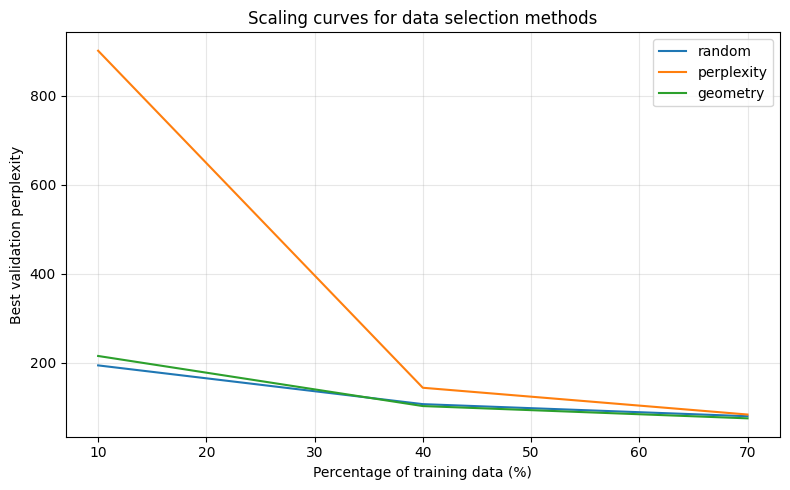

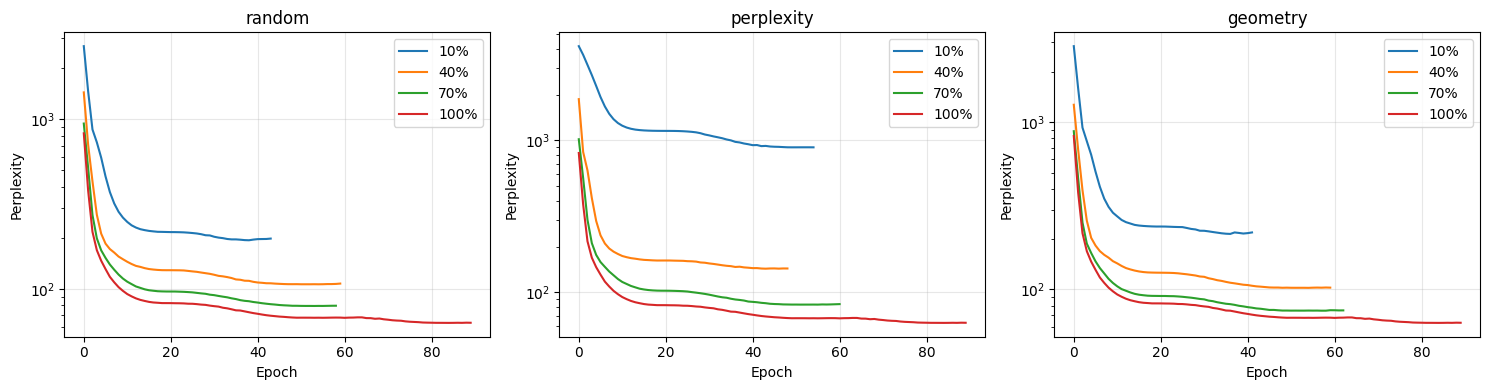

In [76]:
fracs = [0.1, 0.4, 0.7]
results = {m: {} for m in methods}
log_base = 'logs'
for method in ['random', 'perplexity', 'geometry']:
    for frac in [0.1, 0.4, 0.7]:
        folder_name = f'{method}_{int(frac*100)}'
        path = os.path.join(log_base, folder_name)
        version = sorted([d for d in os.listdir(path) if d.startswith('version_')])[-1]
        csv_path = os.path.join(path, version, 'metrics.csv')
        df = pd.read_csv(csv_path)
        best = df['val_ppl'].min()
        results[method][frac] = best
df_full = pd.read_csv('logs/full/version_0/metrics.csv')
full_ppl = df_full['val_ppl'].min()
for method in methods:
    results[method][1.0] = full_ppl

# ========== Построение scaling curves ==========
plt.figure(figsize=(8,5))
for method in methods:
    plt.plot([f * 100 for f in fracs], [results[method][f] for f in fracs], label=method)
plt.xlabel('Percentage of training data (%)')
plt.ylabel('Best validation perplexity')
plt.title('Scaling curves for data selection methods')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== Кривые обучения по эпохам ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, method in enumerate(methods):
    ax = axes[idx]
    for frac in fractions:
        folder_name = f'{method}_{int(frac*100)}'
        path = os.path.join(log_base, folder_name)
        version = sorted([d for d in os.listdir(path) if d.startswith('version_')])[-1]
        csv_path = os.path.join(path, version, 'metrics.csv')
        df = pd.read_csv(csv_path)
        val_rows = df.dropna(subset=['val_ppl'])
        ax.plot(val_rows['epoch'], val_rows['val_ppl'], label=f'{int(frac*100)}%')
    df_full = pd.read_csv('logs/full/version_0/metrics.csv')
    full_val = df_full.dropna(subset=['val_ppl'])
    ax.plot(full_val['epoch'], full_val['val_ppl'], label='100%')
    ax.set_title(method)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Perplexity')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()